# 08 — ULB Generalisation

This notebook evaluates whether the models trained on the IEEE-CIS dataset generalise to a different fraud dataset — the ULB Credit Card Fraud dataset. This tests model robustness across different data distributions.

**Steps:**
1. Load and preprocess ULB data
2. Evaluate RF and XGBoost on ULB
3. Evaluate Autoencoder on ULB
4. Compare results with IEEE-CIS performance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    ConfusionMatrixDisplay,
    confusion_matrix
)
warnings.filterwarnings('ignore')

## 1. Load and Preprocess ULB Data

The ULB dataset has a different structure to IEEE-CIS — 30 features vs 421. We need to align the feature space before applying the trained models.

In [2]:
ulb = pd.read_csv('../data/raw/ulb.csv')
print(f'ULB shape: {ulb.shape}')
print(f'Fraud rate: {ulb["Class"].mean():.4f}')
ulb.head(3)

ULB shape: (284807, 31)
Fraud rate: 0.0017


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [3]:
# Separate features and target
X_ulb = ulb.drop(columns=['Class'])
y_ulb = ulb['Class']

print(f'Features: {X_ulb.shape[1]}')
print(f'Legitimate: {(y_ulb == 0).sum()} | Fraud: {(y_ulb == 1).sum()}')

Features: 30
Legitimate: 284315 | Fraud: 492


In [4]:
# Load IEEE-CIS trained models and feature columns
rf = joblib.load('../results/rf_model.pkl')
xgb = joblib.load('../results/xgb_model.pkl')
ae = tf.keras.models.load_model('../results/ae_model.keras')
scaler = joblib.load('../results/ae_scaler.pkl')
best_threshold = np.load('../results/ae_best_threshold.npy')

# Load IEEE-CIS feature columns
ieee_cols = pd.read_csv('../data/processed/X_test.csv').columns.tolist()

print(f'IEEE-CIS features: {len(ieee_cols)}')
print(f'ULB features: {len(X_ulb.columns)}')

IEEE-CIS features: 421
ULB features: 30


In [5]:
# Align ULB to IEEE-CIS feature space
# Add missing columns as 0, drop extra columns
X_ulb_aligned = X_ulb.reindex(columns=ieee_cols, fill_value=0)

print(f'Aligned ULB shape: {X_ulb_aligned.shape}')
print(f'Columns filled with 0: {len(ieee_cols) - len(X_ulb.columns)}')

Aligned ULB shape: (284807, 421)
Columns filled with 0: 391


## 2. Evaluate RF and XGBoost on ULB

In [6]:
# Random Forest
rf_pred_ulb = rf.predict(X_ulb_aligned)
rf_prob_ulb = rf.predict_proba(X_ulb_aligned)[:, 1]

print('Random Forest — ULB Dataset')
print(classification_report(y_ulb, rf_pred_ulb))
print(f'ROC-AUC: {roc_auc_score(y_ulb, rf_prob_ulb):.4f}')
print(f'PR-AUC:  {average_precision_score(y_ulb, rf_prob_ulb):.4f}')

Random Forest — ULB Dataset
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.00      0.00      0.00       492

    accuracy                           1.00    284807
   macro avg       0.50      0.50      0.50    284807
weighted avg       1.00      1.00      1.00    284807

ROC-AUC: 0.3396
PR-AUC:  0.0012


In [7]:
# XGBoost
xgb_pred_ulb = xgb.predict(X_ulb_aligned)
xgb_prob_ulb = xgb.predict_proba(X_ulb_aligned)[:, 1]

print('XGBoost — ULB Dataset')
print(classification_report(y_ulb, xgb_pred_ulb))
print(f'ROC-AUC: {roc_auc_score(y_ulb, xgb_prob_ulb):.4f}')
print(f'PR-AUC:  {average_precision_score(y_ulb, xgb_prob_ulb):.4f}')

XGBoost — ULB Dataset
              precision    recall  f1-score   support

           0       0.00      0.00      0.00    284315
           1       0.00      1.00      0.00       492

    accuracy                           0.00    284807
   macro avg       0.00      0.50      0.00    284807
weighted avg       0.00      0.00      0.00    284807

ROC-AUC: 0.0718
PR-AUC:  0.0009


## 3. Evaluate Autoencoder on ULB

The Autoencoder uses the same scaler fitted on IEEE-CIS legitimate transactions. Since ULB features are on a different scale, reconstruction errors will be higher overall — the threshold tuned on IEEE-CIS may not transfer well.

In [8]:
X_ulb_scaled = scaler.transform(X_ulb_aligned)
ae_recon_ulb = ae.predict(X_ulb_scaled, verbose=0)
ae_errors_ulb = np.mean(np.power(X_ulb_scaled - ae_recon_ulb, 2), axis=1)
ae_pred_ulb = (ae_errors_ulb > best_threshold).astype(int)

print('Autoencoder — ULB Dataset')
print(classification_report(y_ulb, ae_pred_ulb))
print(f'ROC-AUC: {roc_auc_score(y_ulb, ae_errors_ulb):.4f}')
print(f'PR-AUC:  {average_precision_score(y_ulb, ae_errors_ulb):.4f}')

Autoencoder — ULB Dataset
              precision    recall  f1-score   support

           0       0.00      0.00      0.00    284315
           1       0.00      1.00      0.00       492

    accuracy                           0.00    284807
   macro avg       0.00      0.50      0.00    284807
weighted avg       0.00      0.00      0.00    284807

ROC-AUC: 0.6740
PR-AUC:  0.0470


## 4. Compare IEEE-CIS vs ULB Performance

In [9]:
# Load IEEE-CIS test results for comparison
rf_ieee_probs = pd.read_csv('../results/rf_test_probs.csv').squeeze()
xgb_ieee_probs = pd.read_csv('../results/xgb_test_probs.csv').squeeze()
ae_ieee_errors = pd.read_csv('../results/ae_test_errors.csv').squeeze()
y_ieee_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

comparison = pd.DataFrame({
    'Model': ['RF', 'RF', 'XGBoost', 'XGBoost', 'Autoencoder', 'Autoencoder'],
    'Dataset': ['IEEE-CIS', 'ULB', 'IEEE-CIS', 'ULB', 'IEEE-CIS', 'ULB'],
    'PR-AUC': [
        average_precision_score(y_ieee_test, rf_ieee_probs),
        average_precision_score(y_ulb, rf_prob_ulb),
        average_precision_score(y_ieee_test, xgb_ieee_probs),
        average_precision_score(y_ulb, xgb_prob_ulb),
        average_precision_score(y_ieee_test, ae_ieee_errors),
        average_precision_score(y_ulb, ae_errors_ulb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_ieee_test, rf_ieee_probs),
        roc_auc_score(y_ulb, rf_prob_ulb),
        roc_auc_score(y_ieee_test, xgb_ieee_probs),
        roc_auc_score(y_ulb, xgb_prob_ulb),
        roc_auc_score(y_ieee_test, ae_ieee_errors),
        roc_auc_score(y_ulb, ae_errors_ulb)
    ]
})

comparison = comparison.round(4)
print(comparison.to_string(index=False))

      Model  Dataset  PR-AUC  ROC-AUC
         RF IEEE-CIS  0.6790   0.9239
         RF      ULB  0.0012   0.3396
    XGBoost IEEE-CIS  0.7149   0.9404
    XGBoost      ULB  0.0009   0.0718
Autoencoder IEEE-CIS  0.2351   0.7757
Autoencoder      ULB  0.0470   0.6740


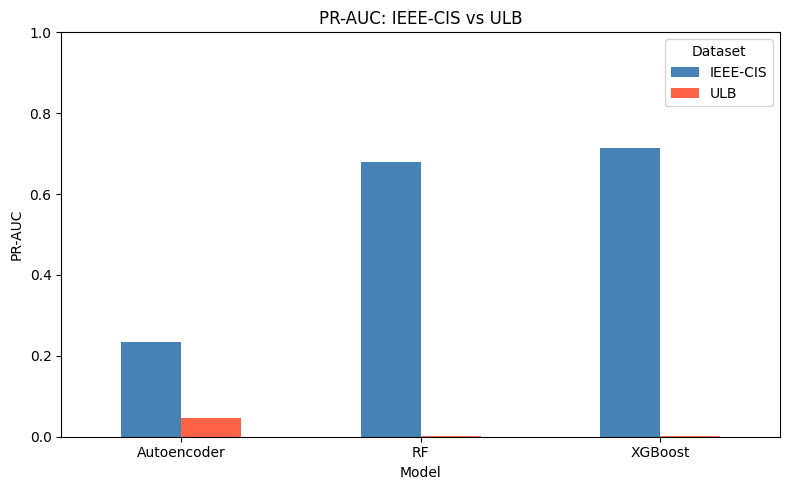

In [10]:
# PR-AUC comparison bar chart
pivot = comparison.pivot(index='Model', columns='Dataset', values='PR-AUC')
pivot.plot(kind='bar', figsize=(8, 5), color=['steelblue', 'tomato'])
plt.title('PR-AUC: IEEE-CIS vs ULB')
plt.ylabel('PR-AUC')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('../results/figures/ulb_comparison.png', dpi=150)
plt.show()

In [11]:
comparison.to_csv('../results/ulb_comparison.csv', index=False)
print('ULB comparison results saved.')

ULB comparison results saved.
